# 06 — フレームワーク比較分析

Chen & Li (2020) の設計に基づく **前処理 → 特徴波長選択 → 回帰モデル** の体系的比較。

| ステップ | 固定 | 比較対象 |
|----------|------|----------|
| 1. サニティチェック | — | raw + NoSelection + PLS |
| 2. 前処理比較 | NoSelection + PLS | 10種類の前処理 |
| 3. 特徴量選択比較 | 最良前処理 + PLS | NoSelection vs CARS |
| 4. モデル比較 | 最良前処理 + 最良選択 | PLS / Ridge / RF / GBM |

> **リーク防止**: 前処理・特徴選択・モデルの fit はすべて outer CV fold の学習データのみで実施。  
> **CV**: GroupKFold(species_number) — 訓練・テストの樹種分離を模倣。

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression

from src.data_io import load_signate
from src.preprocessing import build_preprocessor
from src.feature_selection import NoSelection, CARSSelector
from src.models import get_model
from src.evaluation import compare_pipelines, plot_predictions, print_summary_table
from src.utils import make_submission, setup_japanese_font

plt.rcParams['figure.dpi'] = 110
setup_japanese_font()
print('Setup OK')

Setup OK


In [2]:
# ── データロード ────────────────────────────────────────────────────────────
ds_train = load_signate(split='train')
ds_test  = load_signate(split='test')

X, y, groups, wn = ds_train.X, ds_train.y, ds_train.groups, ds_train.wavelengths
X_test  = ds_test.X

N_SPLITS = 5

print(f'Train  X: {X.shape}  y: [{y.min():.1f}, {y.max():.1f}]')
print(f'Test   X: {X_test.shape}')
print(f'訓練樹種: {sorted(np.unique(groups))}')

Train  X: (1322, 1555)  y: [0.8, 298.6]
Test   X: (550, 1555)
訓練樹種: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]


---
## Step 1 — サニティチェック

最もシンプルな構成で動作確認。RMSE の桁感を把握する。

In [3]:
configs_s1 = [{
    'name':         'raw + NoSel + PLS',
    'preprocessor': build_preprocessor('raw'),
    'selector':     NoSelection(),
    'model':        PLSRegression(n_components=10, scale=False),
}]

df_s1 = compare_pipelines(
    configs_s1, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='step1_sanity.csv',
)
print_summary_table(df_s1, 'Step 1: サニティチェック')

  [raw + NoSel + PLS] RMSE=37.0317±19.8251  R²=0.341  RPD=1.34(poor)  TrainRMSE=16.1904
  → Saved: ..\results\step1_sanity.csv

  Step 1: サニティチェック
                name  CV_RMSE CV_RMSE_std  CV_R2   RPD Train_RMSE
0  raw + NoSel + PLS  37.0317     19.8251  0.341  1.34    16.1904



---
## Step 2 — 前処理比較

モデルを PLS（n_components=10固定）に固定し、前処理のみを変化させて比較する。  
PLS を固定することで前処理の寄与を分離できる。

| 前処理 | 効果 |
|--------|------|
| raw | 無処理（ベースライン） |
| snv | 散乱補正（各スペクトルを行ごと標準化） |
| msc | 多重散乱補正（基準スペクトルへの回帰補正） |
| detrend | 多項式トレンド除去 |
| sg1 / sg2 | SG 1次 / 2次微分（ベースライン・傾き除去） |
| snv+sg1 / snv+sg2 | 散乱補正 → 微分 |
| msc+sg2 / detrend+sg1 | 組み合わせ |

> 所要時間の目安: 約 5〜15 分（CPU依存）

In [4]:
PREP_SPECS = [
    'raw', 'snv', 'msc', 'detrend',
    'sg1', 'sg2',
    'snv+sg1', 'snv+sg2',
    'msc+sg2', 'detrend+sg1',
]

configs_s2 = [
    {
        'name':         spec,
        'preprocessor': build_preprocessor(spec),
        'selector':     NoSelection(),
        'model':        PLSRegression(n_components=10, scale=False),
    }
    for spec in PREP_SPECS
]

df_s2 = compare_pipelines(
    configs_s2, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='step2_preprocessing.csv',
)
print_summary_table(df_s2, 'Step 2: 前処理比較')

  [raw] RMSE=37.0317±19.8251  R²=0.341  RPD=1.34(poor)  TrainRMSE=16.1904
  [snv] RMSE=165.9460±264.0007  R²=-23.465  RPD=0.30(poor)  TrainRMSE=14.9294
  [msc] RMSE=168.4681±297.3719  R²=-28.154  RPD=0.29(poor)  TrainRMSE=16.1162
  [detrend] RMSE=37.0241±14.1013  R²=0.417  RPD=1.34(poor)  TrainRMSE=18.3526
  [sg1] RMSE=81.8120±115.3950  R²=-4.115  RPD=0.61(poor)  TrainRMSE=19.8051
  [sg2] RMSE=66.4588±77.5996  R²=-1.771  RPD=0.75(poor)  TrainRMSE=22.4892
  [snv+sg1] RMSE=108.0655±176.0038  R²=-9.704  RPD=0.46(poor)  TrainRMSE=16.9056
  [snv+sg2] RMSE=47.2221±54.4342  R²=-0.409  RPD=1.05(poor)  TrainRMSE=21.2866
  [msc+sg2] RMSE=73.2678±104.9723  R²=-3.204  RPD=0.68(poor)  TrainRMSE=21.7550
  [detrend+sg1] RMSE=79.4749±111.0814  R²=-3.774  RPD=0.62(poor)  TrainRMSE=19.8182
  → Saved: ..\results\step2_preprocessing.csv

  Step 2: 前処理比較
          name   CV_RMSE CV_RMSE_std    CV_R2   RPD Train_RMSE
0      detrend   37.0241     14.1013    0.417  1.34    18.3526
1          raw   37.0317    

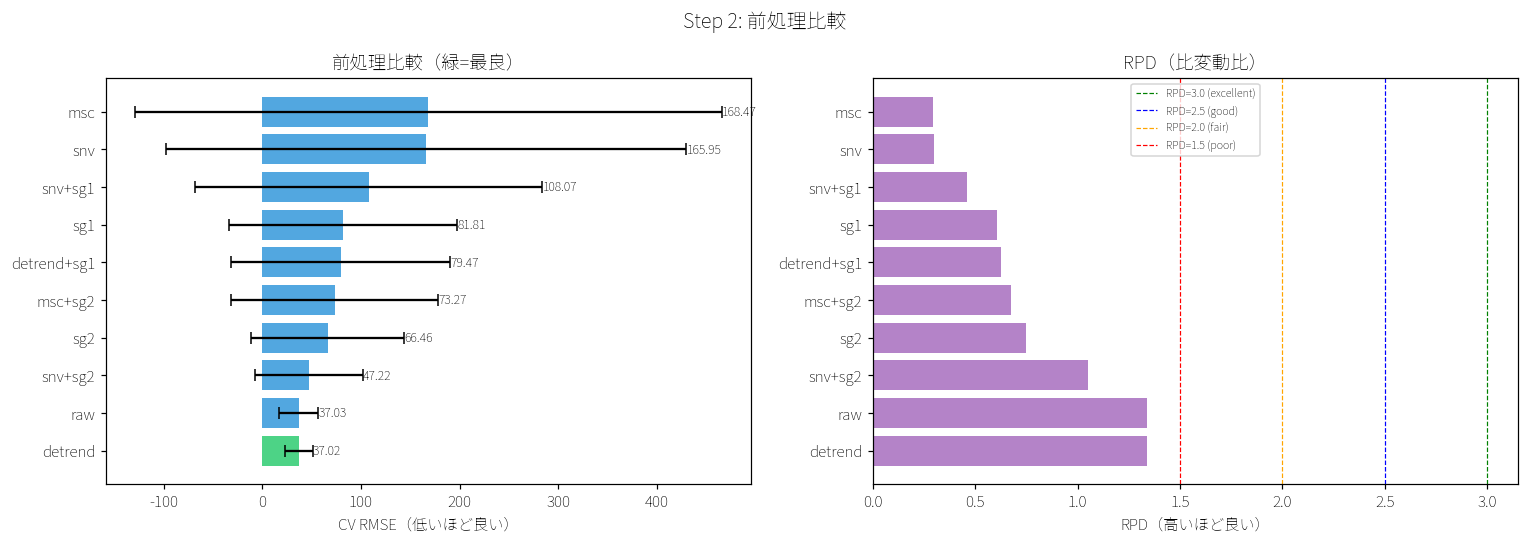


→ 最良前処理: "detrend"  CV RMSE=37.0241


In [5]:
# ── Step 2 可視化 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 棒グラフ（CV RMSE ± std）
ax = axes[0]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_s2))]
ax.barh(df_s2['name'], df_s2['CV_RMSE'], xerr=df_s2['CV_RMSE_std'],
        color=colors, alpha=0.85, capsize=4)
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('前処理比較（緑=最良）')
for i, row in df_s2.iterrows():
    ax.text(row['CV_RMSE'] + row['CV_RMSE_std'] + 0.3, i,
            f"{row['CV_RMSE']:.2f}", va='center', fontsize=8)

# RPD（解釈しやすさ）
ax2 = axes[1]
ax2.barh(df_s2['name'], df_s2['RPD'], color='#9b59b6', alpha=0.75)
for thresh, label, color in [(3.0, 'excellent', 'green'), (2.5, 'good', 'blue'),
                               (2.0, 'fair', 'orange'), (1.5, 'poor', 'red')]:
    ax2.axvline(thresh, linestyle='--', linewidth=0.8, color=color,
                label=f'RPD={thresh} ({label})')
ax2.set_xlabel('RPD（高いほど良い）')
ax2.set_title('RPD（比変動比）')
ax2.legend(fontsize=7)

plt.suptitle('Step 2: 前処理比較', fontsize=13)
plt.tight_layout()
plt.show()

best_prep = str(df_s2.iloc[0]['name'])
print(f'\n→ 最良前処理: "{best_prep}"  CV RMSE={df_s2.iloc[0]["CV_RMSE"]:.4f}')

---
## Step 3 — 特徴波長選択比較

前処理を Step 2 の最良に固定し、特徴選択の効果を検証する。

| 選択法 | 説明 |
|--------|------|
| NoSelection | 全波長（1551本）を使用。ベースライン。 |
| CARS | 競合適応再重み付けサンプリング。指数減衰で1551→2本まで絞り込み、内部CV RMSEが最小の波長セットを選択。 |

> **論文の知見**: 全波長が CARS・SPA より良いケースもある。NoSelection が上回る場合は特徴選択を採用しない。  
> 所要時間の目安: 約 15〜40 分（CARS は 50回ループ × 5-fold × outer 5-fold）

In [6]:
sel_options = [
    ('NoSelection', NoSelection()),
    ('CARS',        CARSSelector(n_components=10, n_runs=50,
                                 cv=5, random_state=42, verbose=False)),
]

configs_s3 = [
    {
        'name':         f'{best_prep} + {sel_name} + PLS',
        'preprocessor': build_preprocessor(best_prep),
        'selector':     sel_obj,
        'model':        get_model('pls'),
    }
    for sel_name, sel_obj in sel_options
]

df_s3 = compare_pipelines(
    configs_s3, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='step3_feature_selection.csv',
)
print_summary_table(df_s3, 'Step 3: 特徴量選択比較')

# 最良セレクタの特定
best_row_name  = str(df_s3.iloc[0]['name'])
name_to_sel    = {f'{best_prep} + {n} + PLS': (n, s) for n, s in sel_options}
best_sel_name, best_sel = name_to_sel[best_row_name]
print(f'\n→ 最良セレクタ: "{best_sel_name}"')

  [detrend + NoSelection + PLS] RMSE=32.3640±15.3809  R²=0.542  RPD=1.53(poor)  TrainRMSE=22.3931
  [detrend + CARS + PLS] RMSE=52.2021±27.1907  R²=-0.514  RPD=0.95(poor)  TrainRMSE=16.5709
  → Saved: ..\results\step3_feature_selection.csv

  Step 3: 特徴量選択比較
                          name  CV_RMSE CV_RMSE_std   CV_R2   RPD Train_RMSE
0  detrend + NoSelection + PLS  32.3640     15.3809   0.542  1.53    22.3931
1         detrend + CARS + PLS  52.2021     27.1907  -0.514  0.95    16.5709


→ 最良セレクタ: "NoSelection"


In [7]:
# ── CARS 選択波長の可視化（全訓練データで再フィット）────────────────────────
if best_sel_name == 'CARS':
    print('全訓練データで CARS を再フィット中...')
    X_prep_all = clone(build_preprocessor(best_prep)).fit_transform(X, y)
    cars_vis = CARSSelector(n_components=10, n_runs=50, cv=5,
                            random_state=42, verbose=True)
    cars_vis.fit(X_prep_all, y)
    mask = cars_vis.support_mask_
    print(f'CARS 選択波長: {mask.sum()} / {len(wn)}')

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    # 平均スペクトル + 選択領域
    mean_spec = X_prep_all.mean(axis=0)
    ax = axes[0]
    ax.plot(wn, mean_spec, linewidth=0.6, color='steelblue', label='平均スペクトル')
    ax.fill_between(wn, mean_spec.min(), mean_spec.max(),
                    where=mask, alpha=0.35, color='orange',
                    label=f'CARS選択 ({mask.sum()}波長)')
    ax.set_xlabel('波数 (cm⁻¹)')
    ax.set_ylabel('吸光度（前処理済み）')
    ax.set_title(f'CARS 選択波長（{best_prep}前処理後）')
    ax.legend()
    ax.invert_xaxis()

    # 選択/非選択のバイナリマスク
    ax2 = axes[1]
    ax2.fill_between(wn, 0, mask.astype(int), step='mid',
                     color='orange', alpha=0.8, label='選択')
    ax2.set_xlabel('波数 (cm⁻¹)')
    ax2.set_ylabel('選択 (1=選択)')
    ax2.set_title('CARS 選択マスク')
    ax2.invert_xaxis()
    ax2.set_ylim(-0.05, 1.2)

    plt.tight_layout()
    plt.show()

elif best_sel_name == 'NoSelection':
    print('最良セレクタは NoSelection（全波長） → 特徴選択は採用しない')

最良セレクタは NoSelection（全波長） → 特徴選択は採用しない


---
## Step 4 — モデル比較

前処理・特徴選択を固定し、回帰モデルを比較する。

| モデル | 特性 |
|--------|------|
| PLS | 線形・低次元・定番ベースライン（n_components を内部CVで自動選択） |
| Ridge | 線形・L2正則化（PLS比較用） |
| RF | 非線形・ランダムフォレスト |
| GBM | 非線形・勾配ブースティング |

> GPR は n=1322 で O(n³) のため除外。  
> 所要時間の目安: 約 10〜30 分

In [8]:
model_keys = ['pls', 'ridge', 'rf', 'gbm']

configs_s4 = [
    {
        'name':         f'{best_prep} + {best_sel_name} + {mkey.upper()}',
        'preprocessor': build_preprocessor(best_prep),
        'selector':     clone(best_sel),
        'model':        get_model(mkey),
    }
    for mkey in model_keys
]

df_s4 = compare_pipelines(
    configs_s4, X, y, groups, n_splits=N_SPLITS,
    save_dir='../results', filename='step4_models.csv',
)
print_summary_table(df_s4, 'Step 4: モデル比較')

best_model_row = df_s4.iloc[0]
best_model_key = model_keys[
    [f'{best_prep} + {best_sel_name} + {k.upper()}' for k in model_keys]
    .index(best_model_row['name'])
]
print(f'\n→ 最良モデル: "{best_model_key.upper()}"  CV RMSE={best_model_row["CV_RMSE"]:.4f}')

  [detrend + NoSelection + PLS] RMSE=32.3640±15.3809  R²=0.542  RPD=1.53(poor)  TrainRMSE=22.3931
  [detrend + NoSelection + RIDGE] RMSE=29.9037±12.7093  R²=0.604  RPD=1.66(poor)  TrainRMSE=20.6596
  [detrend + NoSelection + RF] RMSE=32.0089±11.2452  R²=0.567  RPD=1.55(poor)  TrainRMSE=2.9927
  [detrend + NoSelection + GBM] RMSE=32.1020±11.9251  R²=0.567  RPD=1.54(poor)  TrainRMSE=0.6050
  → Saved: ..\results\step4_models.csv

  Step 4: モデル比較
                            name  CV_RMSE CV_RMSE_std  CV_R2   RPD Train_RMSE
0  detrend + NoSelection + RIDGE  29.9037     12.7093  0.604  1.66    20.6596
1     detrend + NoSelection + RF  32.0089     11.2452  0.567  1.55     2.9927
2    detrend + NoSelection + GBM  32.1020     11.9251  0.567  1.54     0.6050
3    detrend + NoSelection + PLS  32.3640     15.3809  0.542  1.53    22.3931


→ 最良モデル: "RIDGE"  CV RMSE=29.9037


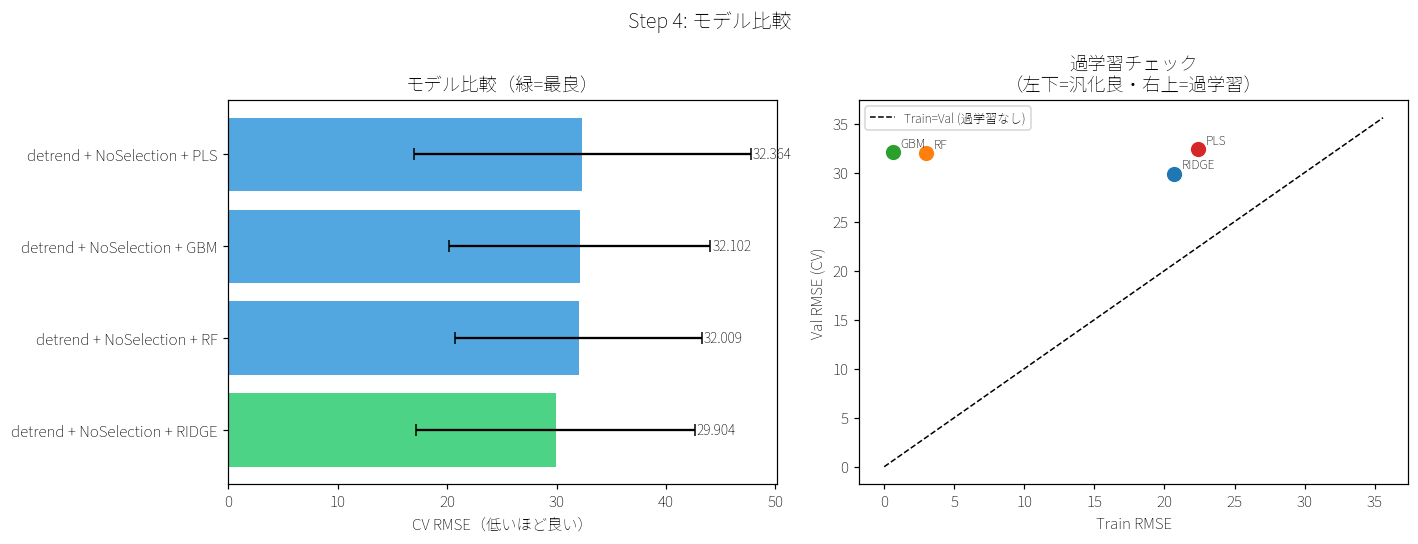

In [9]:
# ── 過学習チェック: Train RMSE vs Val RMSE ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# モデル別 CV RMSE 棒グラフ
ax = axes[0]
colors4 = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_s4))]
ax.barh(df_s4['name'], df_s4['CV_RMSE'], xerr=df_s4['CV_RMSE_std'],
        color=colors4, alpha=0.85, capsize=4)
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('モデル比較（緑=最良）')
for i, row in df_s4.iterrows():
    ax.text(row['CV_RMSE'] + row['CV_RMSE_std'] + 0.2, i,
            f"{row['CV_RMSE']:.3f}", va='center', fontsize=9)

# 過学習チェック散布図
ax2 = axes[1]
for _, row in df_s4.iterrows():
    ax2.scatter(row['Train_RMSE'], row['CV_RMSE'], s=80, zorder=3)
    ax2.annotate(row['name'].split('+')[-1].strip(),
                 (row['Train_RMSE'], row['CV_RMSE']),
                 xytext=(5, 3), textcoords='offset points', fontsize=8)
lims = [0, max(df_s4['CV_RMSE'].max(), df_s4['Train_RMSE'].max()) * 1.1]
ax2.plot(lims, lims, 'k--', linewidth=1, label='Train=Val (過学習なし)')
ax2.set_xlabel('Train RMSE')
ax2.set_ylabel('Val RMSE (CV)')
ax2.set_title('過学習チェック\n（左下=汎化良・右上=過学習）')
ax2.legend(fontsize=8)

plt.suptitle('Step 4: モデル比較', fontsize=13)
plt.tight_layout()
plt.show()

---
## 最良モデルで OOF 予測プロット & 提出ファイル生成

Step 4 の最良構成で out-of-fold 予測を作り、実測 vs 予測を可視化する。  
その後、全訓練データで再フィットしてテスト予測を生成する。

最良構成: detrend + NoSelection + RIDGE
OOF 予測中...


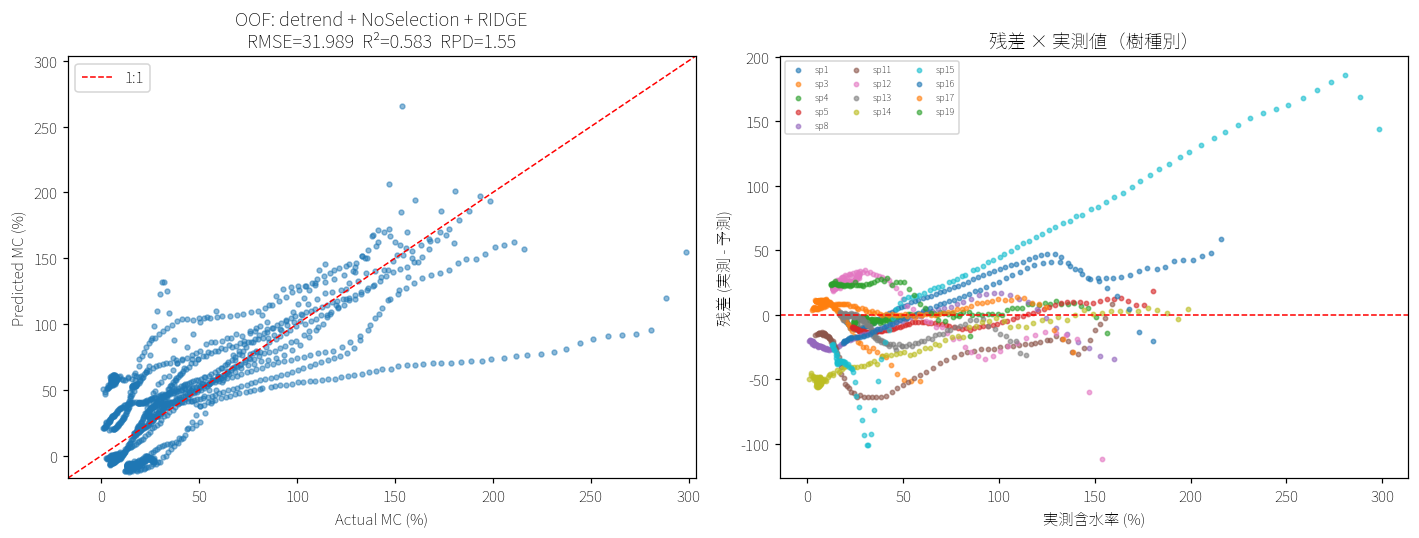

In [10]:
# ── OOF 予測（予測精度の可視化用）────────────────────────────────────────────
print(f'最良構成: {best_prep} + {best_sel_name} + {best_model_key.upper()}')
print('OOF 予測中...')

oof_pred = np.zeros(len(y))
for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
    pipe = Pipeline([
        ('prep',  clone(build_preprocessor(best_prep))),
        ('sel',   clone(best_sel)),
        ('model', clone(get_model(best_model_key))),
    ])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        pipe.fit(X[tr], y[tr])
    oof_pred[va] = pipe.predict(X[va])

# 樹種ごとに色分けした散布図
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_predictions(y, oof_pred,
                 title=f'OOF: {best_prep} + {best_sel_name} + {best_model_key.upper()}',
                 ax=axes[0])

# 樹種ごとの残差分布
ax2 = axes[1]
residuals = y - oof_pred
species_list = sorted(np.unique(groups))
ax2.axhline(0, color='r', linestyle='--', linewidth=1)
for sp in species_list:
    mask_sp = groups == sp
    ax2.scatter(y[mask_sp], residuals[mask_sp], s=8, alpha=0.6, label=f'sp{sp}')
ax2.set_xlabel('実測含水率 (%)')
ax2.set_ylabel('残差 (実測 - 予測)')
ax2.set_title('残差 × 実測値（樹種別）')
ax2.legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

In [11]:
# ── 全訓練データで再フィット → テスト予測 → 提出ファイル ─────────────────────
print('全訓練データで再フィット中...')
final_pipe = Pipeline([
    ('prep',  build_preprocessor(best_prep)),
    ('sel',   clone(best_sel)),
    ('model', get_model(best_model_key)),
])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_pipe.fit(X, y)

test_pred = final_pipe.predict(X_test)
print(f'テスト予測: min={test_pred.min():.2f}  max={test_pred.max():.2f}  mean={test_pred.mean():.2f}')

suffix = f'{best_prep}_{best_sel_name}_{best_model_key}'.replace('+', '_')
sub = make_submission(
    ds_test.meta, test_pred,
    path=f'../submissions/framework_{suffix}.csv'
)
sub.head(10)

全訓練データで再フィット中...
テスト予測: min=6.31  max=185.76  mean=56.23
Saved submission: ../submissions/framework_detrend_NoSelection_ridge.csv


,sample_number,moisture
0,95,185.756375
1,96,159.965572
2,97,151.865601
3,98,148.124915
4,99,143.163044
5,100,137.260242
6,101,132.839866
7,102,129.528521
8,103,126.853536
9,104,125.213274


In [12]:
# ── 全ステップ結果サマリー ─────────────────────────────────────────────────
print('=' * 65)
print('  全ステップ結果サマリー')
print('=' * 65)
print(f'  Step 2 最良前処理 : {best_prep}')
print(f'  Step 3 最良選択   : {best_sel_name}')
print(f'  Step 4 最良モデル : {best_model_key.upper()}')
print(f'  最終 CV RMSE      : {best_model_row["CV_RMSE"]:.4f} ± {best_model_row["CV_RMSE_std"]:.4f}')
print(f'  R²                : {best_model_row["CV_R2"]:.3f}')
print(f'  RPD               : {best_model_row["RPD"]:.2f}')
print(f'  Train RMSE        : {best_model_row["Train_RMSE"]:.4f}')
print(f'  過学習比           : {best_model_row["Overfit_ratio"]:.2f}  (1.0=過学習なし)')
print('=' * 65)

  全ステップ結果サマリー
  Step 2 最良前処理 : detrend
  Step 3 最良選択   : NoSelection
  Step 4 最良モデル : RIDGE
  最終 CV RMSE      : 29.9037 ± 12.7093
  R²                : 0.604
  RPD               : 1.66
  Train RMSE        : 20.6596
  過学習比           : 0.69  (1.0=過学習なし)
